In [1]:
# imports
import numpy as np
import psutil
import torch
import random

from collections import deque
from unityagents import UnityEnvironment

from agent_p3 import MADDPGAgent
from utils_p3 import ReplayBuffer

import matplotlib.pyplot as plt

In [3]:
# start environment
env = UnityEnvironment(
        file_name='Tennis_Windows_x86_64/Tennis.exe',
        no_graphics=True
    )

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


In [4]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]


In [4]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents 
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 2
Size of each action: 2
There are 2 agents. Each observes a state with length: 24
The state for the first agent looks like: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -6.65278625 -1.5
 -0.          0.          6.83172083  6.         -0.          0.        ]


In [9]:
def cleanup_zombie_processes():
    for proc in psutil.process_iter(['pid', 'ppid', 'name', 'status']):
        if proc.info['name'] == 'Reacher_One_Lin' and proc.info['status'] == 'zombie':
            print(f"Zombie process detected: {proc.info}")
            parent = psutil.Process(proc.info['ppid'])
            print(f"Terminating parent process: {parent}")
            parent.terminate()

In [6]:
def train_agents(agents, buffer, env, n_episodes=3000, goal=0.5, train_mode=True, 
                 episode_window=100, print_every=10, batch_size=128, 
                 update_every=5, num_passes=10, max_score=2.5):
    """ Deep Deterministic Policy  Gradient
        Params
    ======
        n_episodes (int): maximum number of training episodes
    """
    mean_scores = []                               # list of mean scores from each episode
    max_scores = []                                # list of highest scores from each episode
    scores_window = deque(maxlen=episode_window)  # mean scores from most recent episodes
    moving_avgs = []                               # list of moving averages
    brain_name = env.brain_names[0]
    
    for i_episode in range(1, n_episodes+1):        
        # Reset the environment
        env_info = env.reset(train_mode=train_mode)[brain_name]
        states = env_info.vector_observations                  # get the current state (for each agent)
        scores = np.zeros(len(env_info.agents))                # initialize the score (for each agent)
        step_num = 0

        for agent in agents:
            agent.reset()
        
        while True:
            #  Select actions for each agent
            actions = np.zeros((num_agents, action_size))
            for i, agent in enumerate(agents):
                # agent.act() already returns numpy array
                actions[i, :] = agent.act(states[i])

            # Step the environment and collect data
            env_info = env.step(actions)[brain_name]        # send all actions to the environment
            next_states = env_info.vector_observations      # get next state (for each agent)
            rewards = env_info.rewards                      # get reward (for each agent)
            dones = env_info.local_done                     # see if episode finished
            
            scores += rewards                               # update the score (for each agent)
    
            # Push to the experience buffer
            for aidx in range(num_agents):
                experience = (states[aidx], actions[aidx], rewards[aidx], 
                            next_states[aidx], dones[aidx], 
                            states, next_states, actions)
                buffer.push(experience)

            # Update the agents once the buffer is sufficiently full
            if len(buffer) > batch_size and step_num % update_every == 0:
                for _ in range(num_passes):
                    samples = buffer.sample(batch_size)
                    for i, agent in enumerate(agents):
                        agent.learn(samples, i, agents)
    
            states = next_states
            step_num += 1

            ## Debugging info
            if np.any(np.array(rewards) > 0):
                print(f"Positive reward at episode {i_episode}, step {step_num}, rewards={rewards}")
    
            if np.any(dones) or max(scores) >= max_score: # exit loop if episode finished
                break
    
        max_scores.append(np.max(scores))             # save highest score for a single agent  
        scores_window.append(np.max(scores))         # save mean score to window
        moving_avgs.append(np.mean(scores_window))    # save moving average
        
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, moving_avgs[i_episode-1]))
        if train_mode and i_episode % print_every == 0:
            for idx in range(num_agents):
                torch.save(agents[idx].actor.state_dict(), 'weights\\actor_trained_weights_'+str(idx)+'.pth') 
                  
        if moving_avgs[-1] >= max_score and i_episode >= episode_window:
            print('\nEnvironment SOLVED in {} episodes!\tMoving Average ={:.1f} over last {} episodes'.format(\
                                    i_episode-episode_window, moving_avgs[-1], episode_window))            
            if train_mode:
                for idx in range(num_agents):
                    torch.save(agents[idx].actor.state_dict(), 'weights\\actor_trained_weights_'+str(idx)+'.pth') 
            break
    goal_vec = np.ones(i_episode)*goal
    return max_scores, moving_avgs, goal_vec

In [5]:
# DDPG Hyperparameters
GAMMA = 0.99            # discount factor
TAU = 1e-3              # for soft update of target parameters

# Replay buffer parameters
BUFFER_SIZE = int(5e5)           # replay buffer size
BATCH_SIZE = 128                 # minibatch size

# Learning rates
LR_ACTOR = 1.9e-4                  # learning rate of the actor
LR_CRITIC = 1e-3                 # learning rate of the critic

# Regularization
WEIGHT_DECAY_ACTOR = 1e-6        # L2 weight decay
WEIGHT_DECAY_CRITIC = 1e-5       # L2 weight decay

# Optimization
CLIP_GRAD = 1.0                  # gradient clipping value
UPDATE_EVERY = 5                 # learning timestep interval
NUM_PASSES = 10                   # number of learning passes

# Exploration
EPSILON = 1.0                    # explore->exploit noise process added to act step
EPSILON_DECAY = 1e-5             # decay rate for noise process

# Training
NUM_EPISODES = 3000              # maximum number of training episodes
PRINT_EVERY = 50                 # print results every n episodes
EPISODE_WINDOW = 100             # moving average window size
GOAL = 0.5                       # goal score to reach
MAX_EPISODE_SCORE = 2.5            # maximum score for an episode (to prevent excessively long episodes)

# Reproducibility by fixing random seed
SEED = 4321
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
# Create agents and replay buffer
agents = [MADDPGAgent(state_size, action_size, num_agents, seed=SEED, gamma=GAMMA, tau=TAU,
                      lr_actor=LR_ACTOR, lr_critic=LR_CRITIC,
                      weight_decay_actor=WEIGHT_DECAY_ACTOR,
                      weight_decay_critic=WEIGHT_DECAY_CRITIC,
                      epsilon=EPSILON, epsilon_decay=EPSILON_DECAY, 
                      clip_grad=CLIP_GRAD) 
          for _ in range(num_agents)]
buffer = ReplayBuffer(size=BUFFER_SIZE)

Episode 1	Average Score: 0.00
Episode 2	Average Score: 0.00
Episode 3	Average Score: 0.00
Episode 4	Average Score: 0.00
Episode 5	Average Score: 0.00
Episode 6	Average Score: 0.00
Episode 7	Average Score: 0.00
Episode 8	Average Score: 0.00
Episode 9	Average Score: 0.00
Episode 10	Average Score: 0.00
Episode 11	Average Score: 0.00
Episode 12	Average Score: 0.00
Episode 13	Average Score: 0.00
Episode 14	Average Score: 0.00
Episode 15	Average Score: 0.00
Episode 16	Average Score: 0.00
Episode 17	Average Score: 0.00
Episode 18	Average Score: 0.00
Episode 19	Average Score: 0.00
Episode 20	Average Score: 0.00
Episode 21	Average Score: 0.00
Episode 22	Average Score: 0.00
Episode 23	Average Score: 0.00
Episode 24	Average Score: 0.00
Episode 25	Average Score: 0.00
Episode 26	Average Score: 0.00
Episode 27	Average Score: 0.00
Positive reward at episode 28, step 17, rewards=[0.0, 0.10000000149011612]
Episode 28	Average Score: 0.00
Episode 29	Average Score: 0.00
Episode 30	Average Score: 0.00
Epis

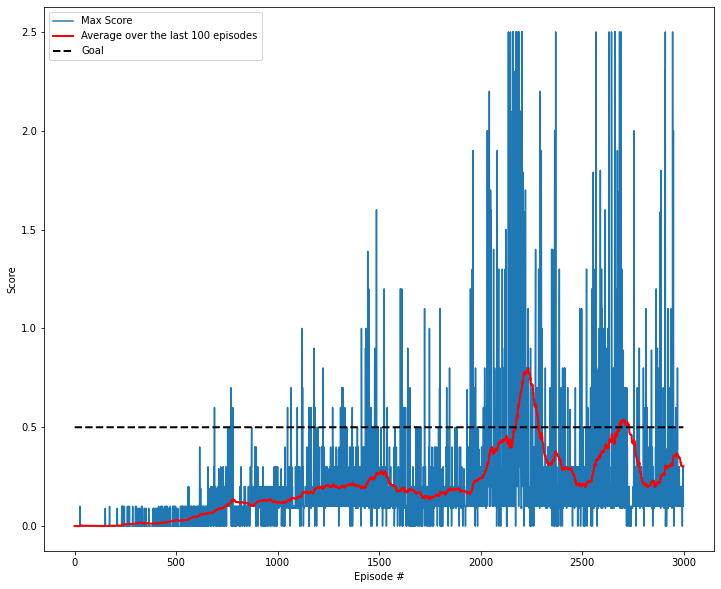

In [9]:
max_scores, moving_avgs, goal_vec = train_agents(agents, buffer, env, n_episodes=NUM_EPISODES, goal=GOAL, train_mode=True, 
                 episode_window=EPISODE_WINDOW, print_every=PRINT_EVERY, batch_size=BATCH_SIZE, 
                 update_every=UPDATE_EVERY, num_passes=NUM_PASSES, max_score=MAX_EPISODE_SCORE)

env.close()

# Check for zombie processes
cleanup_zombie_processes()

# plot the scores
fig = plt.figure(figsize=(12, 10))
plt.plot(np.arange(len(max_scores)), max_scores, label = 'Max Score')
plt.plot(moving_avgs, 'r-', label = 'Average over the last 100 episodes',linewidth = 2)
plt.plot(goal_vec, 'k--',label = 'Goal', linewidth = 2)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.legend()
plt.show()

### Load pretrained weights

In [2]:
# start environment
env = UnityEnvironment(
        file_name='Tennis_Windows_x86_64/Tennis.exe',
        no_graphics=True
    )

# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]


INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


In [3]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents 
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 2
Size of each action: 2
There are 2 agents. Each observes a state with length: 24
The state for the first agent looks like: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -6.65278625 -1.5
 -0.          0.          6.83172083  6.         -0.          0.        ]


In [6]:
agents = [MADDPGAgent(state_size, action_size, num_agents, seed=SEED, gamma=GAMMA, tau=TAU,
                      lr_actor=LR_ACTOR, lr_critic=LR_CRITIC,
                      weight_decay_actor=WEIGHT_DECAY_ACTOR,
                      weight_decay_critic=WEIGHT_DECAY_CRITIC,
                      epsilon=EPSILON, epsilon_decay=EPSILON_DECAY, 
                      clip_grad=CLIP_GRAD) 
          for _ in range(num_agents)]

for idx in range(num_agents):
    agents[idx].actor.load_state_dict(torch.load('weights\\actor_trained_weights_'+str(idx)+'.pth'))

In [7]:

# Reset environment
env_info = env.reset(train_mode=False)[brain_name]  # train_mode=False for inference
states = env_info.vector_observations

while True:
    
    # Choose actions for both players using the trained actor networks
    with torch.no_grad():
        actions = np.zeros((num_agents, action_size))
        for aidx in range(num_agents):
            state_tensor = torch.tensor(states[aidx], dtype=torch.float)
            act_tensor = agents[aidx].actor(state_tensor.cuda())
            actions[aidx, :] = act_tensor.cpu().detach().numpy()

    # Step the environment and collect data
    env_info = env.step(actions)[brain_name]
    next_states = env_info.vector_observations
    rewards = env_info.rewards
    dones = env_info.local_done
    states = next_states

    if np.any(dones):
        break


In [11]:
env.close()

# Check for zombie processes
cleanup_zombie_processes()